# KBO 관중 수 예측

In [34]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / 'data' / 'kbo_attendance.csv'
ARTIFACT_DIR = BASE_DIR / 'artifacts'
ARTIFACT_DIR.mkdir(exist_ok=True)
RIVAL_MATCHES = {tuple(sorted(['LG', '두산']))}


In [35]:
df = pd.read_csv(DATA_PATH)
df.head()

,date,weekday,home_team,away_team,stadium,attendance,is_holiday,weather_main,temp_avg,rain_mm,season
0,2024-03-23,토,KIA,키움,광주,20500,0,????,NaN,NaN,2024
1,2024-03-23,토,KT,삼성,수원,18700,0,????,NaN,NaN,2024
2,2024-03-23,토,LG,한화,잠실,23750,0,????,NaN,NaN,2024
3,2024-03-23,토,NC,두산,창원,17891,0,????,NaN,NaN,2024
4,2024-03-23,토,SSG,롯데,문학,23000,0,????,NaN,NaN,2024


In [36]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['weekday_num'] = df['date'].dt.weekday
df['is_weekend'] = (df['weekday_num'] >= 5).astype(int)
df['is_rival_match'] = df.apply(lambda row: int(tuple(sorted([row['home_team'], row['away_team']])) in RIVAL_MATCHES), axis=1)
df[['date', 'home_team', 'away_team', 'stadium', 'attendance', 'is_weekend', 'is_holiday', 'is_rival_match', 'season']].head()

,date,home_team,away_team,stadium,attendance,is_weekend,is_holiday,is_rival_match,season
0,2024-03-23,KIA,키움,광주,20500,1,0,0,2024
1,2024-03-23,KT,삼성,수원,18700,1,0,0,2024
2,2024-03-23,LG,한화,잠실,23750,1,0,0,2024
3,2024-03-23,NC,두산,창원,17891,1,0,0,2024
4,2024-03-23,SSG,롯데,문학,23000,1,0,0,2024


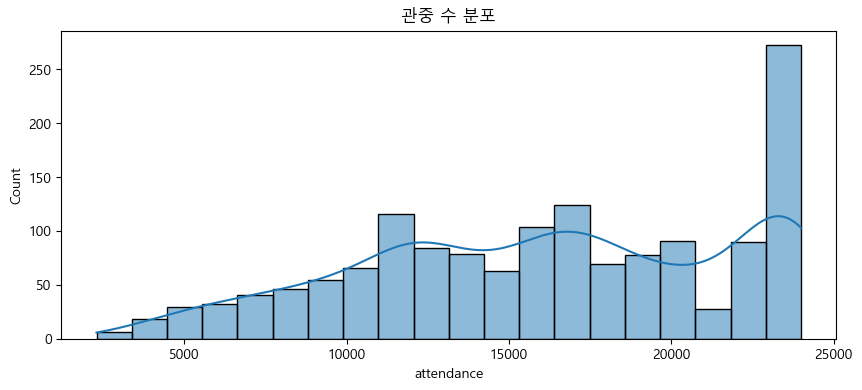

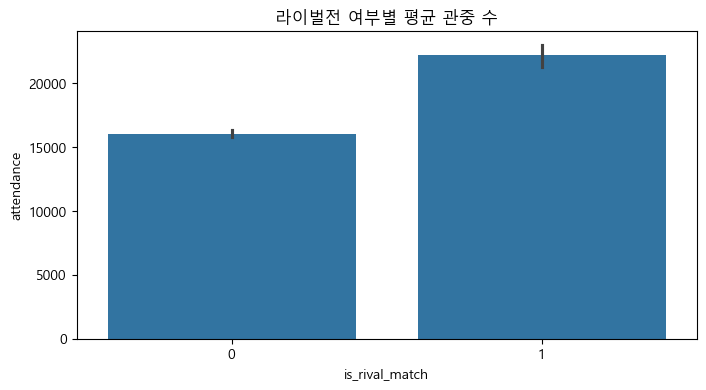

In [37]:
plt.figure(figsize=(10, 4))
sns.histplot(df['attendance'], bins=20, kde=True)
plt.title('관중 수 분포')
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='is_rival_match', y='attendance')
plt.title('라이벌전 여부별 평균 관중 수')
plt.show()

In [38]:
encoders = {}
for col in ['home_team', 'away_team', 'stadium']:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

feature_cols = ['home_team_enc', 'away_team_enc', 'stadium_enc', 'month', 'weekday_num', 'is_weekend', 'is_holiday', 'is_rival_match', 'season']
X = df[feature_cols].copy()
y = df['attendance'].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=1
)

Epoch 1/100


c:\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 292451968.0000 - mae: 16073.9033 - val_loss: 306005472.0000 - val_mae: 16614.0566
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 291920672.0000 - mae: 16057.8008 - val_loss: 304549312.0000 - val_mae: 16571.3516
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 288072928.0000 - mae: 15941.4570 - val_loss: 296248864.0000 - val_mae: 16326.8340
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 272666880.0000 - mae: 15464.8750 - val_loss: 269759264.0000 - val_mae: 15520.9229
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 234713952.0000 - mae: 14228.9297 - val_loss: 214655504.0000 - val_mae: 13683.5039
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 168414784.0000 - mae: 11751.0654 - val_loss: 135055760.0000 - val_mae: 10462.7822
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 94701472.0000 - mae: 8385.5459 - val_loss: 66614972.0000 - val_mae: 6732.1338
Epoch 8/100
60/60 ━━━━━━━━━━━

In [40]:
pred = model.predict(X_test, verbose=0).reshape(-1).astype(float)
y_true = y_test.to_numpy(dtype=float) if hasattr(y_test, 'to_numpy') else np.asarray(y_test, dtype=float)
mae = mean_absolute_error(y_true, pred)
mse = mean_squared_error(y_true, pred)
rmse = np.sqrt(mse)
print({'mae': float(mae), 'rmse': float(rmse)})

{'mae': 3877.1728450083892, 'rmse': 4787.518293774647}


In [41]:
baseline_pred = np.repeat(y_train.mean(), len(y_test))
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
print({'baseline_mae': float(baseline_mae), 'baseline_rmse': float(baseline_rmse)})

{'baseline_mae': 4366.261193189496, 'baseline_rmse': 5254.312661810449}


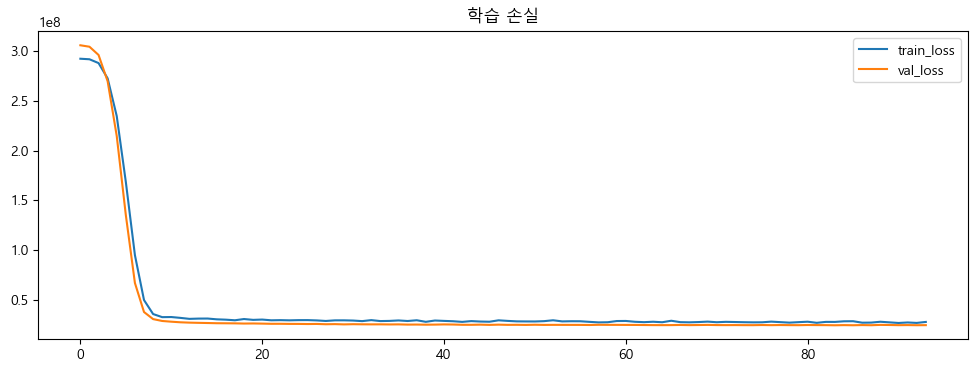

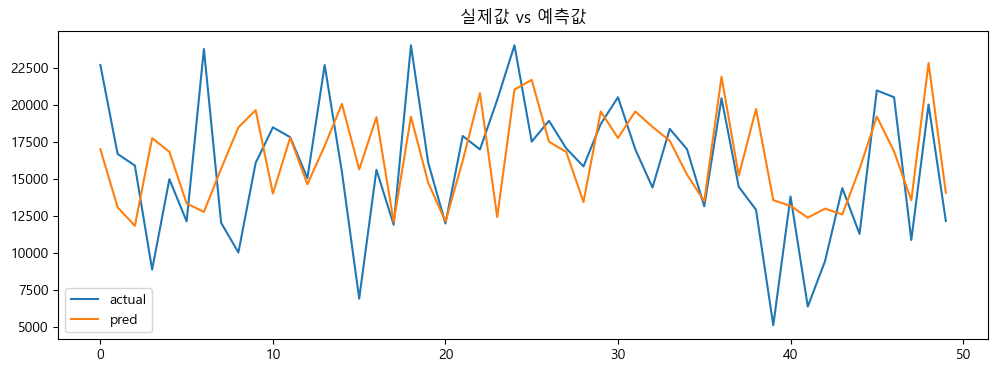

In [42]:
plt.figure(figsize=(12, 4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title('학습 손실')
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(y_true[:50], label='actual')
plt.plot(pred[:50], label='pred')
plt.legend()
plt.title('실제값 vs 예측값')
plt.show()

In [43]:
sample_prediction = int(pred[0]) if len(pred) else 18000
model.save(BASE_DIR / 'models' / 'attendance_dense_model.keras')
with open(ARTIFACT_DIR / 'model_info.json', 'w', encoding='utf-8') as f:
    json.dump({'mae': float(mae), 'rmse': float(rmse), 'sample_prediction': sample_prediction}, f, ensure_ascii=False, indent=2)